## Creates the **Grid File** of a specific region by converting the available shapefile into mutliple (X,Y) coordinate pairs to represent each NUTS3 Unit ##

In [2]:
import pandas as pd

import random
import geopandas as gpd
import numpy as np
import os

import sys

sys.path.insert(0, "../../../../Modules")

from utils import process_greek, create_grid

enc = 'utf-8'
dec = 'greek8'
random.seed(0)
np.random.seed(0)

c:\Users\dimit\AppData\Local\Programs\Python\Python39\lib\site-packages\geopandas\_compat.py:112: UserWarning: The Shapely GEOS version (3.10.3-CAPI-1.16.1) is incompatible with the GEOS version PyGEOS was compiled with (3.10.4-CAPI-1.16.2). Conversions between both will be slow.
  warnings.warn(


In [3]:
import warnings
warnings.filterwarnings('ignore')

In [4]:
NUTS0 = 'GR'
NUTS2 = 'Attica'
NUTS2_ID = 'EL30'

In [5]:
greece_nuts3_gdf = gpd.read_file(f"../../../../Europe NUTS - LAU/Greece/data/EL_Whole.shp",  encoding=enc)

In [6]:
greece_nuts3_gdf.head(5)

,CNTR_CODE,CNTR_NAME,NUTS1_ID,NUTS1_LATN,NUTS1_NAME,NUTS2_ID,NUTS2_LATN,NUTS2_NAME,NUTS3_ID,NUTS3_LATN,NUTS3_NAME,MOUNT_TYPE,URBN_TYPE,COAST_TYPE,geometry
0,EL,Greece,EL3,Attiki,Αττική,EL30,Attiki,Aττική,EL301,Voreios Tomeas Athinon,Βόρειος Τομέας Αθηνών,4.0,1,2,"POLYGON ((23.82310 37.97392, 23.80300 37.98545..."
1,EL,Greece,EL3,Attiki,Αττική,EL30,Attiki,Aττική,EL302,Dytikos Tomeas Athinon,Δυτικός Τομέας Αθηνών,4.0,1,1,"MULTIPOLYGON (((23.72005 38.06296, 23.72884 38..."
2,EL,Greece,EL3,Attiki,Αττική,EL30,Attiki,Aττική,EL303,Kentrikos Tomeas Athinon,Κεντρικός Τομέας Αθηνών,4.0,1,2,"POLYGON ((23.82310 37.97392, 23.82185 37.97195..."
3,EL,Greece,EL3,Attiki,Αττική,EL30,Attiki,Aττική,EL304,Notios Tomeas Athinon,Νότιος Τομέας Αθηνών,4.0,1,1,"POLYGON ((23.80679 37.91784, 23.80240 37.91205..."
4,EL,Greece,EL3,Attiki,Αττική,EL30,Attiki,Aττική,EL305,Anatoliki Attiki,Ανατολική Αττική,2.0,1,1,"MULTIPOLYGON (((24.10518 38.18205, 24.10171 38..."


In [7]:
print(f'greece_nuts3 CRS: {greece_nuts3_gdf.crs}')

greece_nuts3 CRS: GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0],UNIT["Degree",0.0174532925199433],AXIS["Longitude",EAST],AXIS["Latitude",NORTH]]


In [8]:
greece_nuts3_gdf = greece_nuts3_gdf.to_crs(epsg=4326)

In [9]:
print(f'greece_nuts3 CRS: {greece_nuts3_gdf.crs}')

greece_nuts3 CRS: epsg:4326


In [10]:
greece_nuts3_gdf.head(5)

,CNTR_CODE,CNTR_NAME,NUTS1_ID,NUTS1_LATN,NUTS1_NAME,NUTS2_ID,NUTS2_LATN,NUTS2_NAME,NUTS3_ID,NUTS3_LATN,NUTS3_NAME,MOUNT_TYPE,URBN_TYPE,COAST_TYPE,geometry
0,EL,Greece,EL3,Attiki,Αττική,EL30,Attiki,Aττική,EL301,Voreios Tomeas Athinon,Βόρειος Τομέας Αθηνών,4.0,1,2,"POLYGON ((23.82310 37.97392, 23.80300 37.98545..."
1,EL,Greece,EL3,Attiki,Αττική,EL30,Attiki,Aττική,EL302,Dytikos Tomeas Athinon,Δυτικός Τομέας Αθηνών,4.0,1,1,"MULTIPOLYGON (((23.72005 38.06296, 23.72884 38..."
2,EL,Greece,EL3,Attiki,Αττική,EL30,Attiki,Aττική,EL303,Kentrikos Tomeas Athinon,Κεντρικός Τομέας Αθηνών,4.0,1,2,"POLYGON ((23.82310 37.97392, 23.82185 37.97195..."
3,EL,Greece,EL3,Attiki,Αττική,EL30,Attiki,Aττική,EL304,Notios Tomeas Athinon,Νότιος Τομέας Αθηνών,4.0,1,1,"POLYGON ((23.80679 37.91784, 23.80240 37.91205..."
4,EL,Greece,EL3,Attiki,Αττική,EL30,Attiki,Aττική,EL305,Anatoliki Attiki,Ανατολική Αττική,2.0,1,1,"MULTIPOLYGON (((24.10518 38.18205, 24.10171 38..."


In [11]:
print(f'Length of greece_nuts3_gdf: {len(greece_nuts3_gdf)}')

Length of greece_nuts3_gdf: 52


In [12]:
#choose the correct region

nuts2_gdf = greece_nuts3_gdf.loc[greece_nuts3_gdf['NUTS2_ID'] == f'{NUTS2_ID}'].copy()
nuts2_gdf.head()

,CNTR_CODE,CNTR_NAME,NUTS1_ID,NUTS1_LATN,NUTS1_NAME,NUTS2_ID,NUTS2_LATN,NUTS2_NAME,NUTS3_ID,NUTS3_LATN,NUTS3_NAME,MOUNT_TYPE,URBN_TYPE,COAST_TYPE,geometry
0,EL,Greece,EL3,Attiki,Αττική,EL30,Attiki,Aττική,EL301,Voreios Tomeas Athinon,Βόρειος Τομέας Αθηνών,4.0,1,2,"POLYGON ((23.82310 37.97392, 23.80300 37.98545..."
1,EL,Greece,EL3,Attiki,Αττική,EL30,Attiki,Aττική,EL302,Dytikos Tomeas Athinon,Δυτικός Τομέας Αθηνών,4.0,1,1,"MULTIPOLYGON (((23.72005 38.06296, 23.72884 38..."
2,EL,Greece,EL3,Attiki,Αττική,EL30,Attiki,Aττική,EL303,Kentrikos Tomeas Athinon,Κεντρικός Τομέας Αθηνών,4.0,1,2,"POLYGON ((23.82310 37.97392, 23.82185 37.97195..."
3,EL,Greece,EL3,Attiki,Αττική,EL30,Attiki,Aττική,EL304,Notios Tomeas Athinon,Νότιος Τομέας Αθηνών,4.0,1,1,"POLYGON ((23.80679 37.91784, 23.80240 37.91205..."
4,EL,Greece,EL3,Attiki,Αττική,EL30,Attiki,Aττική,EL305,Anatoliki Attiki,Ανατολική Αττική,2.0,1,1,"MULTIPOLYGON (((24.10518 38.18205, 24.10171 38..."


In [13]:
print(f'nuts2_gdf CRS: {nuts2_gdf.crs}')

nuts2_gdf CRS: epsg:4326


<AxesSubplot:>

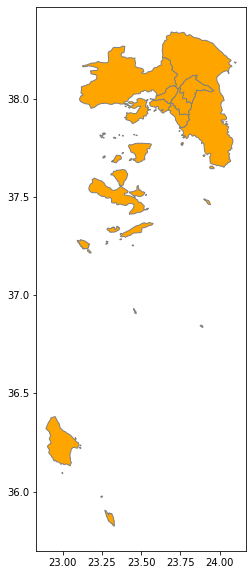

In [14]:
nuts2_gdf.plot(facecolor="none", edgecolor='grey', figsize=(15, 10), color='orange')

In [15]:
nuts2_gdf.NUTS3_NAME.unique()

array(['Βόρειος Τομέας Αθηνών', 'Δυτικός Τομέας Αθηνών',
       'Κεντρικός Τομέας Αθηνών', 'Νότιος Τομέας Αθηνών',
       'Ανατολική Αττική', 'Δυτική Αττική', 'Πειραιάς, Νήσοι'],
      dtype=object)

In [16]:
nuts2_gdf.drop(columns=['CNTR_CODE','CNTR_NAME','NUTS1_ID','NUTS1_LATN','NUTS1_NAME','NUTS2_LATN','NUTS3_LATN',
                        'MOUNT_TYPE','URBN_TYPE','COAST_TYPE'], inplace = True)
nuts2_gdf.reset_index(drop = True, inplace = True)
process_greek(nuts2_gdf, 'NUTS3_NAME')
process_greek(nuts2_gdf, 'NUTS2_NAME')

In [17]:
nuts2_gdf.head(5)

,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,geometry
0,EL30,aττικη,EL301,βορειος τομεας αθηνων,"POLYGON ((23.82310 37.97392, 23.80300 37.98545..."
1,EL30,aττικη,EL302,δυτικος τομεας αθηνων,"MULTIPOLYGON (((23.72005 38.06296, 23.72884 38..."
2,EL30,aττικη,EL303,κεντρικος τομεας αθηνων,"POLYGON ((23.82310 37.97392, 23.82185 37.97195..."
3,EL30,aττικη,EL304,νοτιος τομεας αθηνων,"POLYGON ((23.80679 37.91784, 23.80240 37.91205..."
4,EL30,aττικη,EL305,ανατολικη αττικη,"MULTIPOLYGON (((24.10518 38.18205, 24.10171 38..."


<AxesSubplot:>

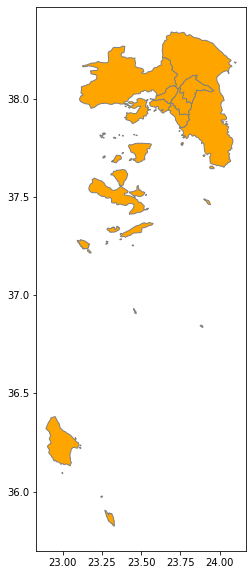

In [18]:
nuts2_gdf.plot(facecolor="none", edgecolor='grey', figsize=(15, 10), color='orange')

In [19]:
nuts3_units = nuts2_gdf['NUTS3_NAME'].unique().tolist()

if not os.path.exists(f'../../data/{NUTS2}/'):
    os.makedirs(f'../../data/{NUTS2}/')

with open(f'../../data/{NUTS2}/{NUTS0}_{NUTS2}_SHP_NUTS3_Units_Processed.txt', 'w', encoding=enc) as f:
    for item in nuts3_units:
        f.write("%s\n" % item)

print(f"Number of NUTS3 Units in {NUTS2} (from shapefile): {len(nuts3_units)}")

Number of NUTS3 Units in Attica (from shapefile): 7


In [20]:
nuts2_gdf.reset_index(inplace=True, drop = True)

In [21]:
empty_gdf = gpd.GeoDataFrame(columns=['geometry'], geometry='geometry', crs='EPSG:4326')

df_grid = create_grid(empty_gdf, nuts2_gdf, col_municipal='NUTS3_NAME', dimension=2)

In [22]:
df_grid.head()

,geometry,centers,NAME,x,y
0,"POLYGON ((23.78937 38.04579, 23.78937 38.06376...",POINT (23.777976934677444 38.05477211220097),βορειος τομεας αθηνων,23.77798,38.05477
1,"POLYGON ((23.81216 38.00986, 23.81216 38.02782...",POINT (23.80076889112907 38.018838729000535),βορειος τομεας αθηνων,23.80077,38.01884
2,"POLYGON ((23.81216 38.02782, 23.81216 38.04579...",POINT (23.80076889112907 38.036805420600764),βορειος τομεας αθηνων,23.80077,38.03681
3,"POLYGON ((23.81216 38.04579, 23.81216 38.06376...",POINT (23.80076889112907 38.05477211220097),βορειος τομεας αθηνων,23.80077,38.05477
4,"POLYGON ((23.81216 38.06376, 23.81216 38.08172...",POINT (23.80076889112907 38.07273880380119),βορειος τομεας αθηνων,23.80077,38.07274


In [23]:
df_grid.rename(columns={"NAME": "NUTS3_NAME"}, inplace = True)

<AxesSubplot:>

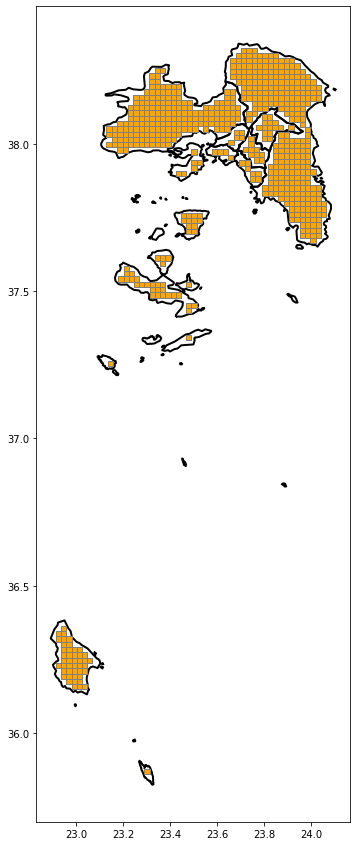

In [24]:
ax = nuts2_gdf.plot(figsize=(15, 15), facecolor="none", edgecolor='black', lw=2)
df_grid.plot(facecolor="none", edgecolor='grey', ax=ax, color='orange')

In [25]:
grid_nuts3 = df_grid['NUTS3_NAME'].unique().tolist()
print(f"Number of NUTS3 Units in Grid: {len(grid_nuts3)}")

Number of NUTS3 Units in Grid: 7


In [26]:
if (len(nuts3_units) != len(grid_nuts3)):
    delta = [item for item in nuts3_units if item not in grid_nuts3]
    print(delta)

    lost_lau1 = nuts2_gdf[nuts2_gdf['NUTS3_NAME'].isin(delta)]
    lost_lau1["centroid"] = lost_lau1["geometry"].centroid

    add_to_nuts2_grid = pd.DataFrame()
    add_to_nuts2_grid['NUTS3_NAME'] = lost_lau1['NUTS3_NAME']
    add_to_nuts2_grid['geometry'] = lost_lau1['geometry']
    add_to_nuts2_grid['x'] = round(lost_lau1['centroid'].x, 5)
    add_to_nuts2_grid['y'] = round(lost_lau1['centroid'].y, 5)

    lost_lau1.plot(facecolor="none", edgecolor='grey', figsize=(10, 10), color='orange')

In [27]:
nuts2_grid = df_grid.drop(columns=['centers'])

In [28]:
nuts2_grid

,geometry,NUTS3_NAME,x,y
0,"POLYGON ((23.78937 38.04579, 23.78937 38.06376...",βορειος τομεας αθηνων,23.77798,38.05477
1,"POLYGON ((23.81216 38.00986, 23.81216 38.02782...",βορειος τομεας αθηνων,23.80077,38.01884
2,"POLYGON ((23.81216 38.02782, 23.81216 38.04579...",βορειος τομεας αθηνων,23.80077,38.03681
3,"POLYGON ((23.81216 38.04579, 23.81216 38.06376...",βορειος τομεας αθηνων,23.80077,38.05477
4,"POLYGON ((23.81216 38.06376, 23.81216 38.08172...",βορειος τομεας αθηνων,23.80077,38.07274
...,...,...,...,...
619,"POLYGON ((23.53474 37.92708, 23.53474 37.94505...","πειραιας, νησοι",23.52366,37.93606
620,"POLYGON ((23.60121 37.96301, 23.60121 37.98098...","πειραιας, νησοι",23.59013,37.97200
621,"POLYGON ((23.62337 37.96301, 23.62337 37.98098...","πειραιας, νησοι",23.61229,37.97200
622,"POLYGON ((23.64553 37.96301, 23.64553 37.98098...","πειραιας, νησοι",23.63445,37.97200


In [29]:
if (len(nuts3_units) != len(grid_nuts3)):
    nuts2_grid = pd.concat([nuts2_grid, add_to_nuts2_grid], axis=0)

nuts2_grid.reset_index(inplace=True, drop=True)

In [30]:
nuts2_grid.rename(columns={"geometry": "shape"}, inplace=True)

In [31]:
nuts2_grid

,shape,NUTS3_NAME,x,y
0,"POLYGON ((23.78937 38.04579, 23.78937 38.06376...",βορειος τομεας αθηνων,23.77798,38.05477
1,"POLYGON ((23.81216 38.00986, 23.81216 38.02782...",βορειος τομεας αθηνων,23.80077,38.01884
2,"POLYGON ((23.81216 38.02782, 23.81216 38.04579...",βορειος τομεας αθηνων,23.80077,38.03681
3,"POLYGON ((23.81216 38.04579, 23.81216 38.06376...",βορειος τομεας αθηνων,23.80077,38.05477
4,"POLYGON ((23.81216 38.06376, 23.81216 38.08172...",βορειος τομεας αθηνων,23.80077,38.07274
...,...,...,...,...
619,"POLYGON ((23.53474 37.92708, 23.53474 37.94505...","πειραιας, νησοι",23.52366,37.93606
620,"POLYGON ((23.60121 37.96301, 23.60121 37.98098...","πειραιας, νησοι",23.59013,37.97200
621,"POLYGON ((23.62337 37.96301, 23.62337 37.98098...","πειραιας, νησοι",23.61229,37.97200
622,"POLYGON ((23.64553 37.96301, 23.64553 37.98098...","πειραιας, νησοι",23.63445,37.97200


In [32]:
nuts2_grid_points = gpd.GeoDataFrame(nuts2_grid, geometry=gpd.points_from_xy(nuts2_grid.x, nuts2_grid.y))

In [33]:
nuts2_grid_points

,shape,NUTS3_NAME,x,y,geometry
0,"POLYGON ((23.78937 38.04579, 23.78937 38.06376...",βορειος τομεας αθηνων,23.77798,38.05477,POINT (23.77798 38.05477)
1,"POLYGON ((23.81216 38.00986, 23.81216 38.02782...",βορειος τομεας αθηνων,23.80077,38.01884,POINT (23.80077 38.01884)
2,"POLYGON ((23.81216 38.02782, 23.81216 38.04579...",βορειος τομεας αθηνων,23.80077,38.03681,POINT (23.80077 38.03681)
3,"POLYGON ((23.81216 38.04579, 23.81216 38.06376...",βορειος τομεας αθηνων,23.80077,38.05477,POINT (23.80077 38.05477)
4,"POLYGON ((23.81216 38.06376, 23.81216 38.08172...",βορειος τομεας αθηνων,23.80077,38.07274,POINT (23.80077 38.07274)
...,...,...,...,...,...
619,"POLYGON ((23.53474 37.92708, 23.53474 37.94505...","πειραιας, νησοι",23.52366,37.93606,POINT (23.52366 37.93606)
620,"POLYGON ((23.60121 37.96301, 23.60121 37.98098...","πειραιας, νησοι",23.59013,37.97200,POINT (23.59013 37.97200)
621,"POLYGON ((23.62337 37.96301, 23.62337 37.98098...","πειραιας, νησοι",23.61229,37.97200,POINT (23.61229 37.97200)
622,"POLYGON ((23.64553 37.96301, 23.64553 37.98098...","πειραιας, νησοι",23.63445,37.97200,POINT (23.63445 37.97200)


<AxesSubplot:>

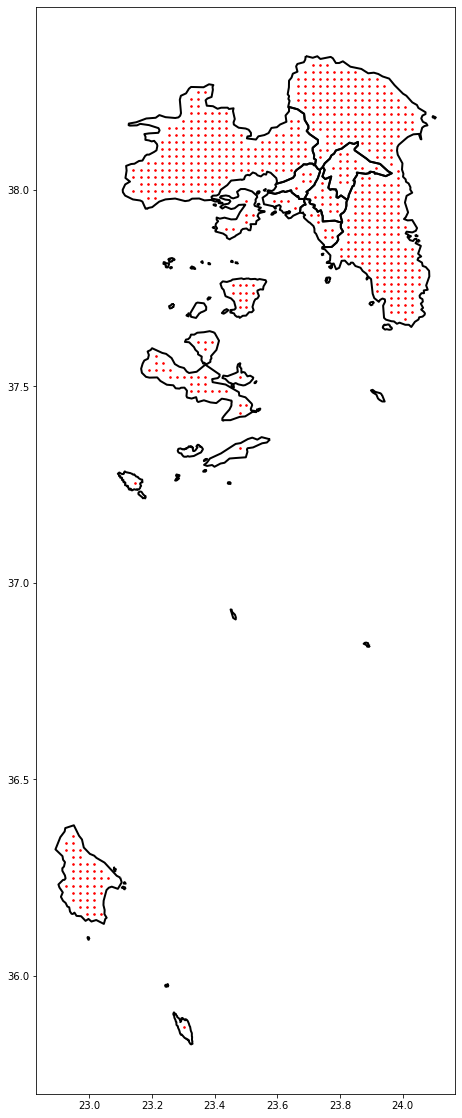

In [34]:
ax = nuts2_grid_points.plot(markersize=2.5, figsize=(20, 20), color='red')
nuts2_gdf.plot(facecolor="none", edgecolor='black', ax=ax, lw=2)

In [35]:
final_grid = pd.merge(nuts2_grid[['NUTS3_NAME', 'x', 'y']], nuts2_gdf[['NUTS2_ID','NUTS2_NAME','NUTS3_ID','NUTS3_NAME']], how='left', on=['NUTS3_NAME']) 
final_grid.sort_values(by=['NUTS3_NAME'], inplace = True)
final_grid = final_grid[['NUTS2_ID', 'NUTS2_NAME', 'NUTS3_ID', 'NUTS3_NAME', 'x', 'y']]

final_grid.reset_index(drop = True, inplace= True)

In [36]:
final_grid

,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,x,y
0,EL30,aττικη,EL305,ανατολικη αττικη,24.00727,37.83228
1,EL30,aττικη,EL305,ανατολικη αττικη,23.91651,37.92212
2,EL30,aττικη,EL305,ανατολικη αττικη,23.91651,37.90415
3,EL30,aττικη,EL305,ανατολικη αττικη,23.91651,37.88618
4,EL30,aττικη,EL305,ανατολικη αττικη,23.91651,37.86822
...,...,...,...,...,...,...
619,EL30,aττικη,EL307,"πειραιας, νησοι",22.99184,36.24719
620,EL30,aττικη,EL307,"πειραιας, νησοι",22.99184,36.22923
621,EL30,aττικη,EL307,"πειραιας, νησοι",22.99184,36.21126
622,EL30,aττικη,EL307,"πειραιας, νησοι",22.99184,36.17533


In [37]:
final_grid['NUTS2_NAME'] = 'αττικη'

In [38]:
final_grid

,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,x,y
0,EL30,αττικη,EL305,ανατολικη αττικη,24.00727,37.83228
1,EL30,αττικη,EL305,ανατολικη αττικη,23.91651,37.92212
2,EL30,αττικη,EL305,ανατολικη αττικη,23.91651,37.90415
3,EL30,αττικη,EL305,ανατολικη αττικη,23.91651,37.88618
4,EL30,αττικη,EL305,ανατολικη αττικη,23.91651,37.86822
...,...,...,...,...,...,...
619,EL30,αττικη,EL307,"πειραιας, νησοι",22.99184,36.24719
620,EL30,αττικη,EL307,"πειραιας, νησοι",22.99184,36.22923
621,EL30,αττικη,EL307,"πειραιας, νησοι",22.99184,36.21126
622,EL30,αττικη,EL307,"πειραιας, νησοι",22.99184,36.17533


In [39]:
final_grid.NUTS3_NAME.unique()

array(['ανατολικη αττικη', 'βορειος τομεας αθηνων', 'δυτικη αττικη',
       'δυτικος τομεας αθηνων', 'κεντρικος τομεας αθηνων',
       'νοτιος τομεας αθηνων', 'πειραιας, νησοι'], dtype=object)

In [40]:
final_grid.to_csv(f'../../data/{NUTS2}/{NUTS0}_{NUTS2}_Grid_NUTS3.csv', encoding=enc, index = False)